# Finding networks in a complex system

A community (also called a cluster or module) is a group of nodes in a graph that are more densely connected to each other than to the rest of the network.

In [30]:
def readNetwork(filename):
	with open(filename, 'r') as file:
		net = { 'noNodes' : int(file.readline()) }

		matrix: list = []
		degree: list = []
		noEdges = 0

		for _ in range(net['noNodes']):
			matrix.append([])
			for node in file.readline().split():
				matrix[-1].append(int(node))
			degree.append(sum(matrix[-1]))
			noEdges += degree[-1]

		net['matrix'] = matrix
		net['degree'] = degree
		net['noEdges'] = noEdges

		return net

In [31]:
network = readNetwork('data/graph.in')

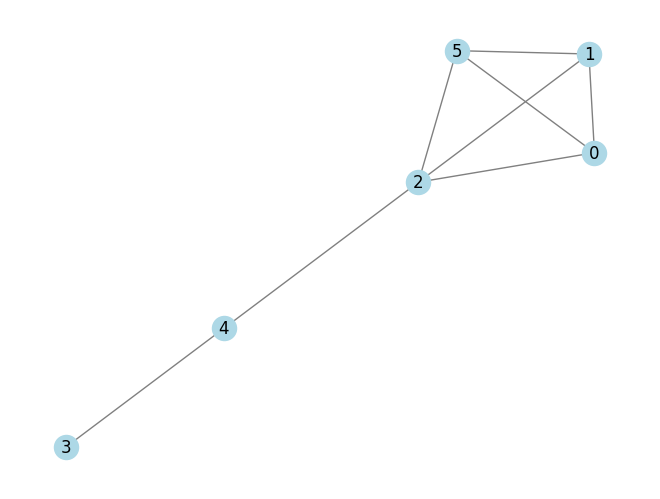

In [32]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

A = np.array(network['matrix'])
G = nx.from_numpy_array(A)
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

**Greedy Modularity** it works by iteratively merging communities that result in the largest increase in modularity until no further improvement can be made. Modularity is a measure of the strength of division of a network into communities, with higher values indicating stronger community structure. The algorithm starts with each node as its own community and merges them based on the modularity gain until it reaches a local maximum.

In [33]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

n = network['noNodes']
partition = [0] * n
for community_id, nodes in enumerate(communities):
	for node in nodes:
		partition[node] = community_id

print(partition)

[0, 0, 0, 1, 1, 0]


In [34]:
def modularity(G, partition):
	pos = nx.spring_layout(G)
	plt.figure(figsize=(8, 6))
	nx.draw_networkx_nodes(G, pos, node_color=partition, cmap=plt.cm.Set3, node_size=300)
	nx.draw_networkx_edges(G, pos, edge_color='gray')
	plt.title('Community Detection using Greedy Modularity')
	plt.axis('off')
	plt.show()

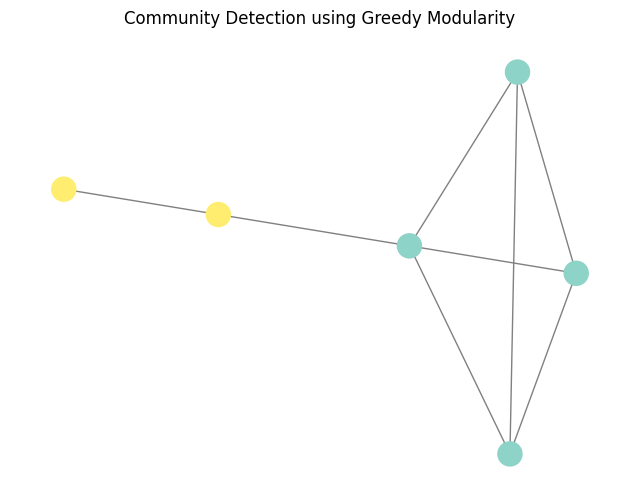

In [35]:
modularity(G, partition)

## Community with Genetic Algorithm

Genetic algorithms are optimization techniques inspired by the process of natural selection. 

Now to do this we must first understand what we work with. We have a chromosome, we want to transform with chromosome into communities. Every index is a node, and the value of the chromosome[index] is the community that the node belongs to.

For the fetness function we will use modularity, from `networkx` library. What does this function do? It measures the strength of division of a network into communities. A higher modularity value indicates a stronger community structure, meaning that there are more edges within communities than between them.

In [36]:
from networkx.algorithms import community as nx_community

def chromosomeToCommunities(chromosome, nodes):
    communities = {}
    for idx, comm_id in enumerate(chromosome):
        communities.setdefault(comm_id, set()).add(nodes[idx])
    return list(communities.values())


def fitness(chromosome, G, nodes):
    """Modularity Q — higher is better."""
    communities = chromosomeToCommunities(chromosome, nodes)
    if len(communities) == 1:
        return 0.0
    return nx_community.modularity(G, communities)

Now that we know what we work with, we can start the second part: population. Every chromosome is just a vector of size n with random values between 0 and n (the number of nodes).

In [37]:
import random 

def randomChromosome(n_nodes, n_communities):
    return [random.randint(0, n_communities - 1) for _ in range(n_nodes)]


def initPopulation(pop_size, n_nodes, n_communities):
    return [randomChromosome(n_nodes, n_communities) for _ in range(pop_size)]

For reproduction we will want to mate the best chromosomes. We need a `tornament selection` to select the best chromosomes. We don't want have the entire population the the tornament, we want to have a random sample because we want to have some diversity in the population. If we would use the entire population, we would have a very low diversity and we would get stuck in a local maximum.

In [38]:
def tournamentSelection(population, fitnesses, tournament_size):
    contestants_idx = random.sample(range(len(population)), tournament_size)
    best_idx = max(contestants_idx, key=lambda i: fitnesses[i])
    return population[best_idx]

For mateing we will use `one point crossover`. We will select a random point in the chromosome and we will swap the values of the two parents after that point. This way we will create two children that are a combination of the two parents.

In [39]:
def singlePointCrossover(parent1, parent2):
    n = len(parent1)
    cut = random.randint(1, n - 1)  # at least 1 gene from each parent
    child = parent1[:cut] + parent2[cut:]
    return child

We want to have some m-mrrr-mmmrr-mutation to find better solutions. We wan't our children like this!
![Mutation Example](data/cat.png)

In [40]:
def mutate(chromosome, mutation_rate, n_communities):
    mutated = chromosome[:]
    for i in range(len(mutated)):
        if random.random() < mutation_rate:
            mutated[i] = random.randint(0, n_communities - 1)
    return mutated

In [41]:
def geneticAlgorithm(G, n_communities, pop_size=100, generations=200, mutation_rate=0.05, tournament_size=5):
    
    n_nodes = G.number_of_nodes()
    nodes = list(G.nodes())

    population = initPopulation(pop_size, n_nodes, n_communities)
    fitnesses = [fitness(ch, G, nodes) for ch in population]

    best_chromosome = max(population, key=lambda ch: fitness(ch, G, nodes))
    best_fitness = fitness(best_chromosome, G, nodes)

    print(f"Gen 0 — best modularity: {best_fitness:.4f}")

    for gen in range(1, generations + 1):
        new_population = []

        for _ in range(pop_size):
            parent1 = tournamentSelection(population, fitnesses, tournament_size)
            parent2 = tournamentSelection(population, fitnesses, tournament_size)
            child = singlePointCrossover(parent1, parent2)
            child = mutate(child, mutation_rate, n_communities)
            new_population.append(child)

        population = new_population
        fitnesses = [fitness(ch, G, nodes) for ch in population]

        gen_best = max(population, key=lambda ch: fitness(ch, G, nodes))
        gen_best_fit = fitness(gen_best, G, nodes)

        if gen_best_fit > best_fitness:
            best_fitness = gen_best_fit
            best_chromosome = gen_best[:]

        if gen % 20 == 0:
            print(f"Gen {gen} — best modularity: {best_fitness:.4f}")

    print(f"\nFinal best modularity: {best_fitness:.4f}")
    print(f"Communities found: {len(set(best_chromosome))}")
    return best_chromosome, best_fitness, nodes

In [42]:
A = np.array(network['matrix'])
G = nx.from_numpy_array(A)

best_partition, _, _ = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)

print("\nPartition:", best_partition)

Gen 0 — best modularity: 0.0703
Gen 20 — best modularity: 0.1797
Gen 40 — best modularity: 0.1797
Gen 60 — best modularity: 0.1797
Gen 80 — best modularity: 0.1797
Gen 100 — best modularity: 0.1797
Gen 120 — best modularity: 0.1797
Gen 140 — best modularity: 0.1797
Gen 160 — best modularity: 0.1797
Gen 180 — best modularity: 0.1797
Gen 200 — best modularity: 0.1797

Final best modularity: 0.1797
Communities found: 2

Partition: [3, 3, 3, 2, 2, 3]


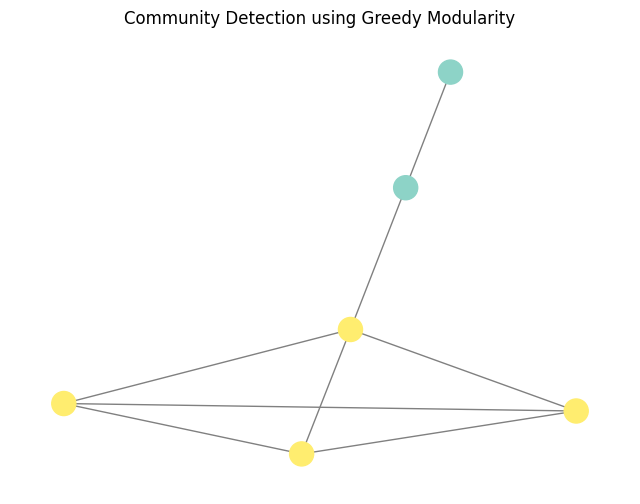

In [43]:
modularity(G, best_partition)

In [64]:
def communitiesToPartition(communities, G: nx.Graph):
    nodes = list(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    
    partition = [0] * len(nodes)
    for community_id, comm_nodes in enumerate(communities):
        for node in comm_nodes:
            partition[node_to_idx[node]] = community_id
    
    return partition

def modularity_two(G: nx.Graph, partition_me, partition_library):
	pos = nx.spring_layout(G)
	partition_library = communitiesToPartition(partition_library, G)

	plt.figure(figsize=(12, 6))

	plt.subplot(1, 2, 1)
	nx.draw_networkx_nodes(G, pos, node_color=partition_me, cmap=plt.cm.Set3, node_size=300)
	nx.draw_networkx_edges(G, pos, edge_color='gray')
	plt.title('Genetic Algorithm Partition')
	plt.axis('off')

	plt.subplot(1, 2, 2)
	nx.draw_networkx_nodes(G, pos, node_color=partition_library, cmap=plt.cm.Set3, node_size=300)
	nx.draw_networkx_edges(G, pos, edge_color='gray')
	plt.title('Library Partition')
	plt.axis('off')

	plt.show()

Gen 0 — best modularity: 0.0657
Gen 20 — best modularity: 0.3226
Gen 40 — best modularity: 0.4048
Gen 60 — best modularity: 0.4238
Gen 80 — best modularity: 0.4461
Gen 100 — best modularity: 0.4660
Gen 120 — best modularity: 0.4882
Gen 140 — best modularity: 0.4931
Gen 160 — best modularity: 0.4937
Gen 180 — best modularity: 0.4969
Gen 200 — best modularity: 0.5119

Final best modularity: 0.5119
Communities found: 4


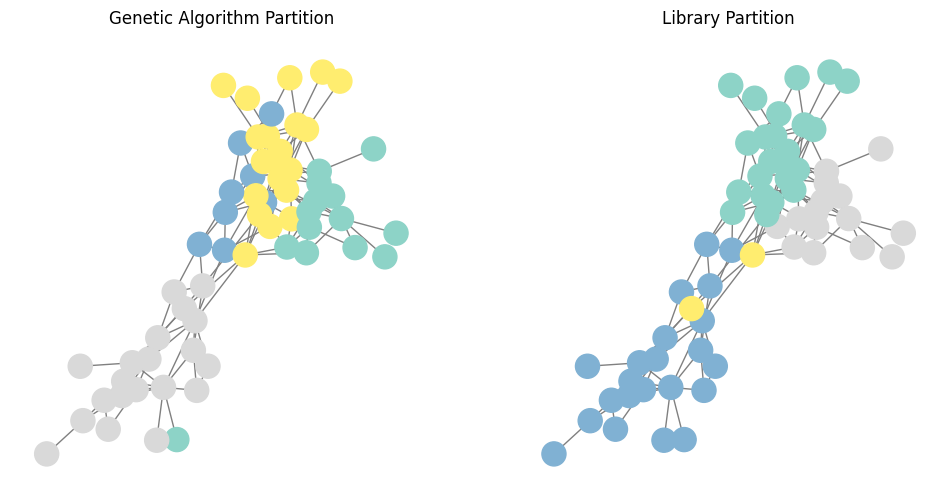

In [ ]:
G = nx.read_gml('data/real-networks/real/dolphins/dolphins.gml')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)

best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

Whos fotball data is this???
```python
NetworkXError: edge #51 (27--17) is duplicated
```

In [45]:
def read_gml_safe(path):
    with open(path, 'r') as f:
        lines = f.readlines()

    edges_seen = set()
    in_edge    = False
    source     = None
    target     = None

    for line in lines:
        stripped = line.strip()

        if stripped == 'edge':          
            in_edge        = True
            source, target = None, None

        elif in_edge:
            if stripped == '[':         
                continue
            elif stripped.startswith('source'):
                source = int(stripped.split()[1])
            elif stripped.startswith('target'):
                target = int(stripped.split()[1])
            elif stripped == ']':
                in_edge = False
                if source is not None and target is not None:
                    edge_key = (min(source, target), max(source, target))
                    edges_seen.add(edge_key)

    G = nx.Graph()
    G.add_edges_from(edges_seen)

    return G

Gen 0 — best modularity: 0.0371
Gen 20 — best modularity: 0.2130
Gen 40 — best modularity: 0.2838
Gen 60 — best modularity: 0.3210
Gen 80 — best modularity: 0.3419
Gen 100 — best modularity: 0.3561
Gen 120 — best modularity: 0.3561
Gen 140 — best modularity: 0.3758
Gen 160 — best modularity: 0.3758
Gen 180 — best modularity: 0.3758
Gen 200 — best modularity: 0.3758

Final best modularity: 0.3758
Communities found: 4


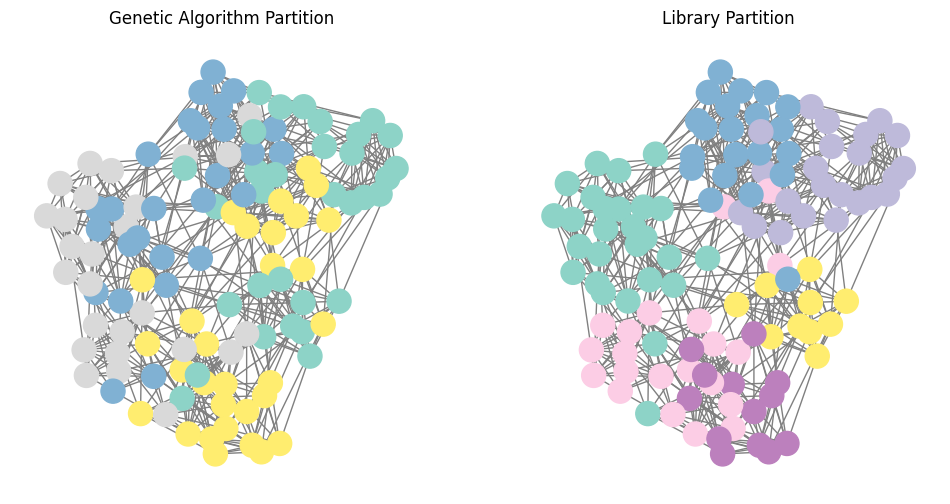

In [66]:
G = read_gml_safe('data/real-networks/real/football/football.gml')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)

best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

Gen 0 — best modularity: 0.1257
Gen 20 — best modularity: 0.3400
Gen 40 — best modularity: 0.3748
Gen 60 — best modularity: 0.3755
Gen 80 — best modularity: 0.3755
Gen 100 — best modularity: 0.3755
Gen 120 — best modularity: 0.3755
Gen 140 — best modularity: 0.3755
Gen 160 — best modularity: 0.3755
Gen 180 — best modularity: 0.3755
Gen 200 — best modularity: 0.3755

Final best modularity: 0.3755
Communities found: 3


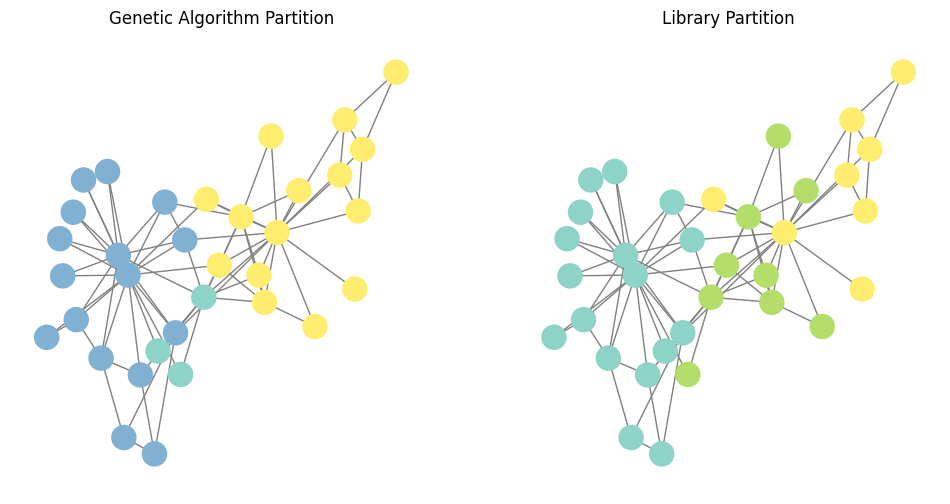

In [68]:
G = nx.read_gml('data/real-networks/real/karate/karate.gml', label='id')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)
    
best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

Gen 0 — best modularity: 0.0563
Gen 20 — best modularity: 0.2073
Gen 40 — best modularity: 0.3078
Gen 60 — best modularity: 0.3581
Gen 80 — best modularity: 0.3920
Gen 100 — best modularity: 0.4038
Gen 120 — best modularity: 0.4140
Gen 140 — best modularity: 0.4160
Gen 160 — best modularity: 0.4160
Gen 180 — best modularity: 0.4160
Gen 200 — best modularity: 0.4160

Final best modularity: 0.4160
Communities found: 4


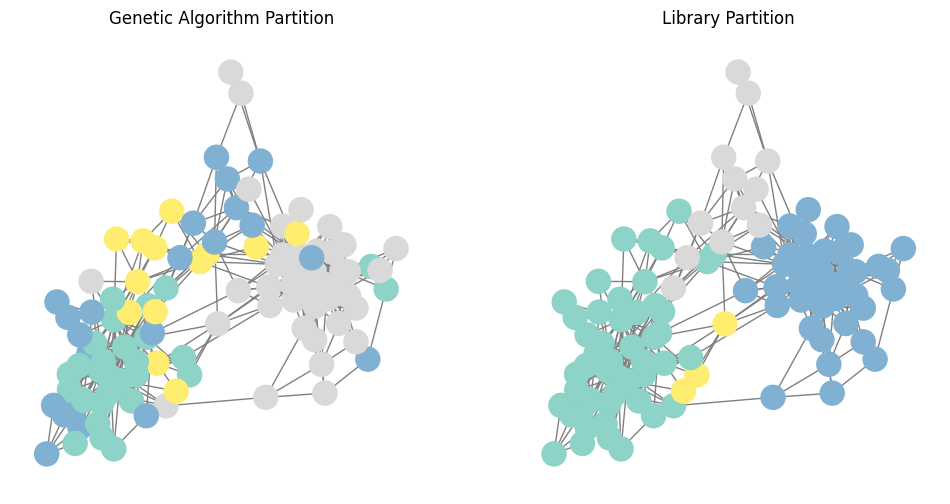

In [69]:
G = nx.read_gml('data/real-networks/real/krebs/krebs.gml')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)
    
best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

For the communities that we have to find I will just use the ones form `networkx` library. It is a cheachy way to complete the assigment? yes.

> [doc](https://networkx.org/documentation/stable/reference/generated/networkx.generators.intersection.uniform_random_intersection_graph.html)

Gen 0 — best modularity: 0.0918
Gen 20 — best modularity: 0.3962
Gen 40 — best modularity: 0.4689
Gen 60 — best modularity: 0.4963
Gen 80 — best modularity: 0.4963
Gen 100 — best modularity: 0.5004
Gen 120 — best modularity: 0.5023
Gen 140 — best modularity: 0.5127
Gen 160 — best modularity: 0.5139
Gen 180 — best modularity: 0.5139
Gen 200 — best modularity: 0.5168

Final best modularity: 0.5168
Communities found: 4


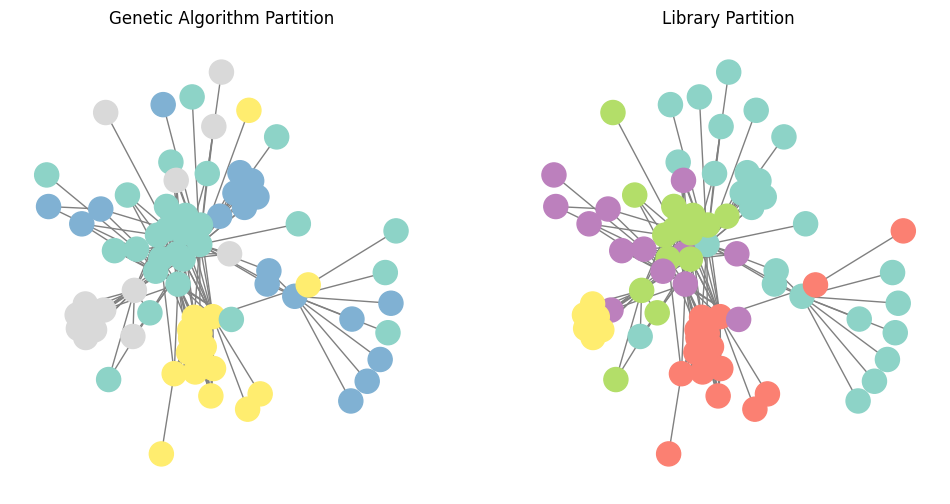

In [70]:
G = nx.les_miserables_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)
    
best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

Gen 0 — best modularity: 0.0926
Gen 20 — best modularity: 0.2209
Gen 40 — best modularity: 0.3058
Gen 60 — best modularity: 0.3225
Gen 80 — best modularity: 0.3250
Gen 100 — best modularity: 0.3330
Gen 120 — best modularity: 0.3349
Gen 140 — best modularity: 0.3349
Gen 160 — best modularity: 0.3349
Gen 180 — best modularity: 0.3349
Gen 200 — best modularity: 0.3349

Final best modularity: 0.3349
Communities found: 4


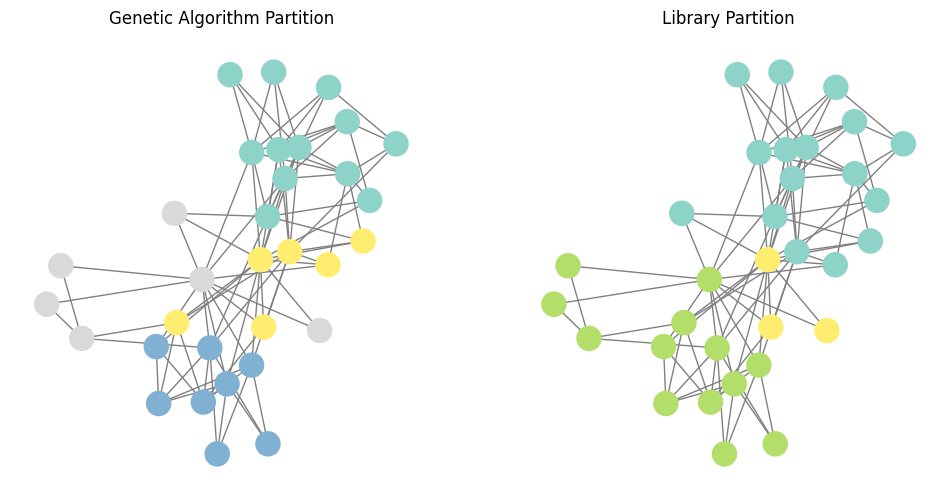

In [71]:
G = nx.davis_southern_women_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)
    
best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

Gen 0 — best modularity: 0.2375
Gen 20 — best modularity: 0.3987
Gen 40 — best modularity: 0.3987
Gen 60 — best modularity: 0.3987
Gen 80 — best modularity: 0.3987
Gen 100 — best modularity: 0.3987
Gen 120 — best modularity: 0.3987
Gen 140 — best modularity: 0.3987
Gen 160 — best modularity: 0.3987
Gen 180 — best modularity: 0.3987
Gen 200 — best modularity: 0.3987

Final best modularity: 0.3987
Communities found: 3


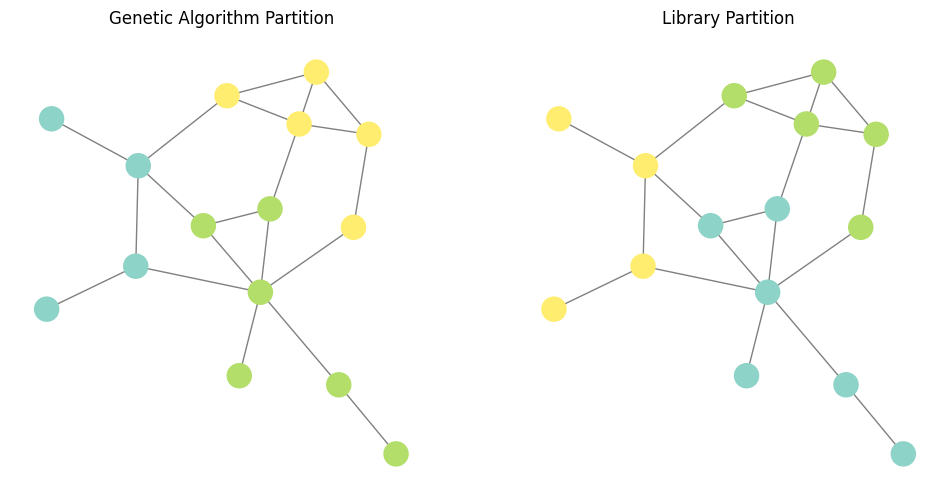

In [72]:
G = nx.florentine_families_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)
    
best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

In [ ]:
G = nx.karate_club_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)
    
best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)

Gen 0 — best modularity: 0.0866
Gen 20 — best modularity: 0.3880
Gen 40 — best modularity: 0.4345
Gen 60 — best modularity: 0.4345
Gen 80 — best modularity: 0.4345
Gen 100 — best modularity: 0.4345
Gen 120 — best modularity: 0.4345
Gen 140 — best modularity: 0.4345
Gen 160 — best modularity: 0.4345


Gen 0 — best modularity: 0.0183
Gen 20 — best modularity: 0.1329
Gen 40 — best modularity: 0.2190
Gen 60 — best modularity: 0.2612
Gen 80 — best modularity: 0.2821
Gen 100 — best modularity: 0.2831
Gen 120 — best modularity: 0.2866
Gen 140 — best modularity: 0.2924
Gen 160 — best modularity: 0.2926
Gen 180 — best modularity: 0.2933
Gen 200 — best modularity: 0.2933

Final best modularity: 0.2933
Communities found: 4


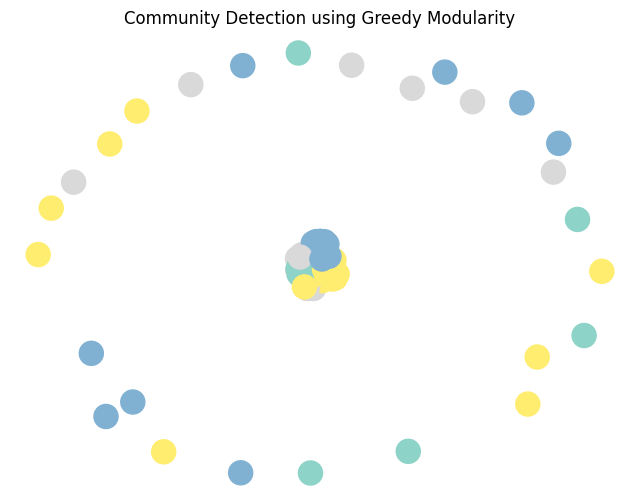

In [ ]:
G = nx.uniform_random_intersection_graph(100, 10, 0.1)

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)
    
best_partition_library = community.greedy_modularity_communities(G)

modularity_two(G, best_partition, best_partition_library)